In [1]:
!pip install pgmpy --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 38.8 MB/s eta 0:00:00


In [9]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination
from pgmpy.estimators import BayesianEstimator
from pgmpy.sampling import BayesianModelSampling
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [17]:
student_model = DiscreteBayesianNetwork([
    ('C', 'W'),
    ('T', 'W'),
    ('T', 'I'),
    ('S', 'I'),
    ('W', 'J'),
    ('I', 'J')
])

In [18]:
cpd_C = TabularCPD('C', 3, [[0.2], [0.5], [0.3]], state_names={'C': ['Low', 'Med', 'High']})
cpd_T = TabularCPD('T', 2, [[0.4], [0.6]], state_names={'T': ['Weak', 'Strong']})
cpd_S = TabularCPD('S', 2, [[0.5], [0.5]], state_names={'S': ['Weak', 'Strong']})

In [39]:
cpd_W = TabularCPD(
    'W', 2,
    [[0.8, 0.6, 0.3, 0.4, 0.2, 0.1],
     [0.2, 0.4, 0.7, 0.6, 0.8, 0.9]],
    evidence=['C', 'T'], evidence_card=[3, 2],
    state_names={'W': ['Fail', 'Pass'],
                 'C': ['Low', 'Med', 'High'],
                 'T': ['Weak', 'Strong']})

cpd_I = TabularCPD(
    'I', 2,
    [[0.7, 0.4, 0.3, 0.1],
     [0.3, 0.6, 0.7, 0.9]],
    evidence=['T', 'S'], evidence_card=[2, 2],
    state_names={'I': ['Fail', 'Pass'],
                 'T': ['Weak', 'Strong'],
                 'S': ['Weak', 'Strong']})

cpd_J = TabularCPD(
    'J', 2,
    [[0.99, 0.8, 0.6, 0.1],
     [0.01, 0.2, 0.4, 0.9]],
    evidence=['W', 'I'], evidence_card=[2, 2],
    state_names={'J': ['No', 'Yes'],
                 'W': ['Fail', 'Pass'],
                 'I': ['Fail', 'Pass']})

In [40]:
student_model.add_cpds(cpd_C, cpd_T, cpd_S, cpd_W, cpd_I, cpd_J)
assert student_model.check_model()

In [41]:
inf = VariableElimination(student_model)

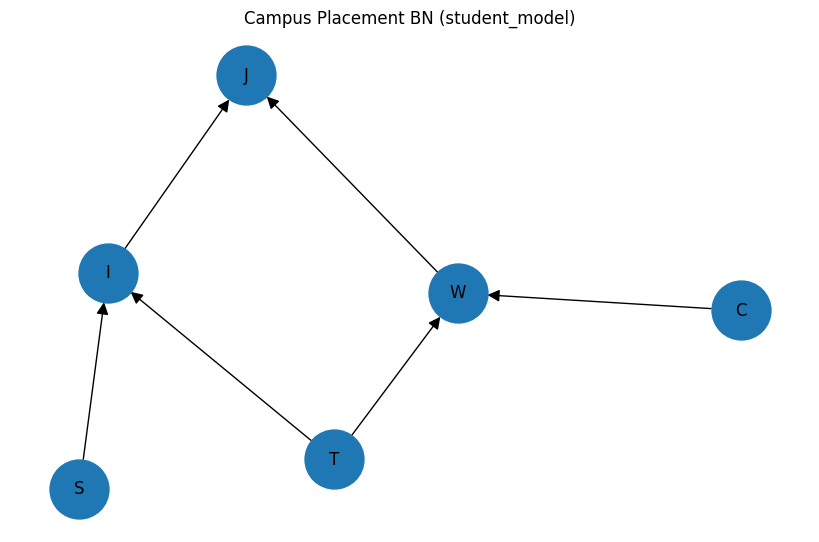

In [42]:
G = nx.DiGraph()
G.add_nodes_from(student_model.nodes())
G.add_edges_from(student_model.edges())
pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(8,5))
nx.draw(G, pos, with_labels=True, node_size=1800, font_size=12, arrowsize=18)
plt.title("Campus Placement BN (student_model)")
plt.show()

In [43]:
q1 = inf.query(['J'])
print("P(J):\n", q1)

P(J):
 +--------+----------+
| J      |   phi(J) |
+========+==========+
| J(No)  |   0.4823 |
+--------+----------+
| J(Yes) |   0.5177 |
+--------+----------+


In [44]:
q2 = inf.query(['J'], evidence={'C': 'High', 'T': 'Strong'})
print("\nP(J | C=High, T=Strong):\n", q2)


P(J | C=High, T=Strong):
 +--------+----------+
| J      |   phi(J) |
+========+==========+
| J(No)  |   0.2638 |
+--------+----------+
| J(Yes) |   0.7362 |
+--------+----------+


In [45]:
q3 = inf.query(['T'], evidence={'J': 'Yes'})
print("\nP(T | J=Yes):\n", q3)


P(T | J=Yes):
 +-----------+----------+
| T         |   phi(T) |
+===========+==========+
| T(Weak)   |   0.3316 |
+-----------+----------+
| T(Strong) |   0.6684 |
+-----------+----------+


In [46]:
q4a = inf.query(['W'], evidence={'J': 'Yes'})
q4b = inf.query(['W'], evidence={'J': 'Yes', 'I': 'Pass'})
print("\nP(W=Pass | J=Yes):\n", q4a)
print("\nP(W=Pass | J=Yes, I=Pass):\n", q4b)


P(W=Pass | J=Yes):
 +---------+----------+
| W       |   phi(W) |
+=========+==========+
| W(Fail) |   0.0930 |
+---------+----------+
| W(Pass) |   0.9070 |
+---------+----------+

P(W=Pass | J=Yes, I=Pass):
 +---------+----------+
| W       |   phi(W) |
+=========+==========+
| W(Fail) |   0.1092 |
+---------+----------+
| W(Pass) |   0.8908 |
+---------+----------+


In [47]:
data = student_model.simulate(n_samples=20000, show_progress=False)
learned_model = DiscreteBayesianNetwork(student_model.edges())
learned_model.fit(data, state_names={
    'C': ['Low', 'Med', 'High'],
    'T': ['Weak', 'Strong'],
    'S': ['Weak', 'Strong'],
    'W': ['Fail', 'Pass'],
    'I': ['Fail', 'Pass'],
    'J': ['No', 'Yes']
})

In [48]:
print("\nLearned CPD for J | W,I:")
print(learned_model.get_cpds('J'))


Learned CPD for J | W,I:
+--------+----------------------+-----+--------------------+
| I      | I(Fail)              | ... | I(Pass)            |
+--------+----------------------+-----+--------------------+
| W      | W(Fail)              | ... | W(Pass)            |
+--------+----------------------+-----+--------------------+
| J(No)  | 0.9886868686868687   | ... | 0.0989395175387484 |
+--------+----------------------+-----+--------------------+
| J(Yes) | 0.011313131313131313 | ... | 0.9010604824612516 |
+--------+----------------------+-----+--------------------+


In [49]:
data = student_model.simulate(n_samples=20000, seed=42, show_progress=False)
print("Sample of generated data (first 5 rows):")
display(data.head())

learned_model = DiscreteBayesianNetwork(student_model.edges())

learned_model.fit(data, state_names={
    'C': ['Low', 'Med', 'High'],
    'T': ['Weak', 'Strong'],
    'S': ['Weak', 'Strong'],
    'W': ['Fail', 'Pass'],
    'I': ['Fail', 'Pass'],
    'J': ['No', 'Yes']
})

print("\nOriginal CPD for J | W,I (from specification):")
display(cpd_J)

print("\nLearned CPD for J | W,I:")
learned_cpd_J = learned_model.get_cpds('J')
display(learned_cpd_J)

cols = []
for w in ['Fail','Pass']:
    for i in ['Fail','Pass']:
        cols.append(f"W={w},I={i}")

learned_values_2d = learned_cpd_J.values.reshape(learned_cpd_J.cardinality[0], -1)

df_learned = pd.DataFrame(learned_values_2d, index=['No','Yes'], columns=cols)
display(df_learned)

Sample of generated data (first 5 rows):


,J,C,W,I,S,T
0,No,Med,Fail,Pass,Weak,Strong
1,Yes,High,Pass,Pass,Weak,Weak
2,Yes,High,Pass,Fail,Weak,Weak
3,Yes,Med,Pass,Pass,Weak,Strong
4,No,Low,Pass,Fail,Weak,Strong



Original CPD for J | W,I (from specification):


<TabularCPD representing P(J:2 | W:2, I:2) at 0x7a43be8a8110>


Learned CPD for J | W,I:


<TabularCPD representing P(J:2 | I:2, W:2) at 0x7a43bf4f2270>

,"W=Fail,I=Fail","W=Fail,I=Pass","W=Pass,I=Fail","W=Pass,I=Pass"
No,0.992354,0.59605,0.788482,0.099645
Yes,0.007646,0.40395,0.211518,0.900355
